In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

In [4]:
# Create copy

clean_df = df.copy()

# Fill CouponCode missing values

clean_df["CouponCode"] = clean_df["CouponCode"].fillna("No Coupon")

# Convert Date

clean_df["Date"] = pd.to_datetime(clean_df["Date"])

print(clean_df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [5]:
# Date Features

clean_df["Year"] = clean_df["Date"].dt.year
clean_df["Month"] = clean_df["Date"].dt.month
clean_df["Day"] = clean_df["Date"].dt.day

# Revenue per Item

clean_df["RevenuePerItem"] = (
    clean_df["TotalPrice"] /
    clean_df["Quantity"]
)

clean_df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,RevenuePerItem
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,4,570.62
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,23,151.35
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,27,550.68
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,15,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,8,626.01


In [6]:
product_revenue = (
    clean_df
    .groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

,TotalPrice
Product,
Chair,195620.11
Printer,195612.61
Laptop,192126.56
Tablet,186568.95
Monitor,175651.41
Desk,167459.93
Phone,151722.39


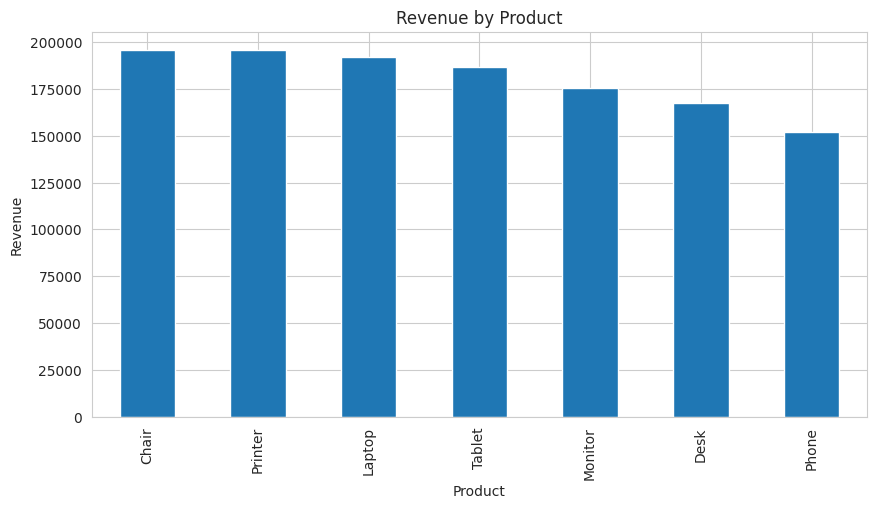

In [7]:
plt.figure(figsize=(10,5))

product_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Product")
plt.ylabel("Revenue")

plt.show()

In [8]:
status_counts = clean_df["OrderStatus"].value_counts()

status_counts

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


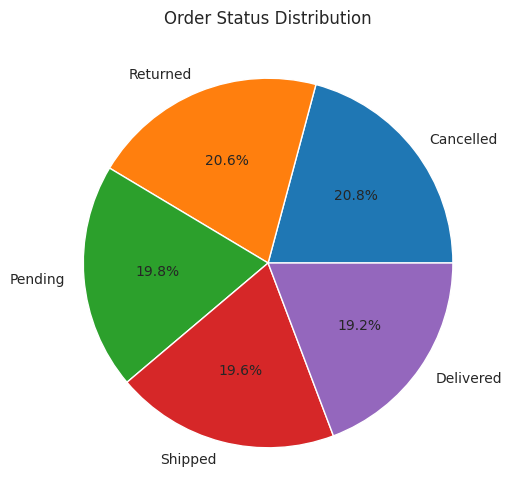

In [9]:
plt.figure(figsize=(6,6))

status_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Order Status Distribution")

plt.show()

In [10]:
payment_revenue = (
    clean_df
    .groupby("PaymentMethod")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

,TotalPrice
PaymentMethod,
Credit Card,263847.63
Online,262442.94
Cash,259786.29
Gift Card,246323.92
Debit Card,232361.18


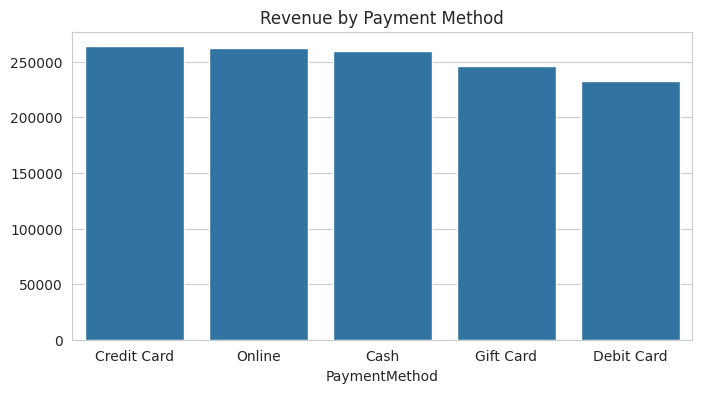

In [11]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values
)

plt.title("Revenue by Payment Method")

plt.show()

In [12]:
referral_revenue = (
    clean_df
    .groupby("ReferralSource")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

referral_revenue

,TotalPrice
ReferralSource,
Instagram,275285.45
Email,261808.55
Google,250441.48
Facebook,250410.90
Referral,226815.58


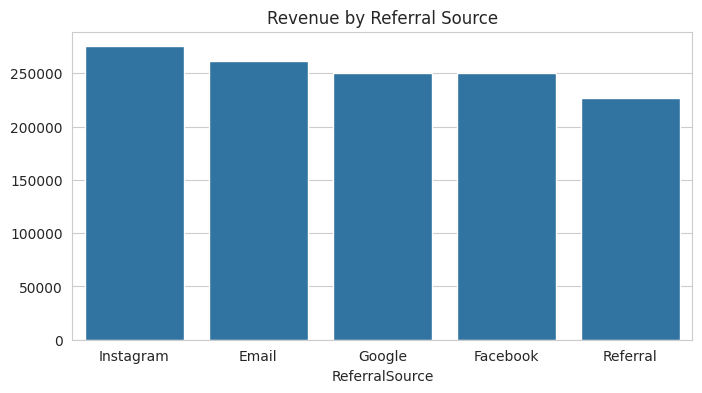

In [13]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=referral_revenue.index,
    y=referral_revenue.values
)

plt.title("Revenue by Referral Source")

plt.show()

In [14]:
monthly_revenue = (
    clean_df
    .groupby("Month")["TotalPrice"]
    .sum()
)

monthly_revenue

,TotalPrice
Month,
1,124313.23
2,112344.78
3,123840.93
4,109186.05
5,135142.59
6,170616.13
7,85784.64
8,86343.21
9,69321.65


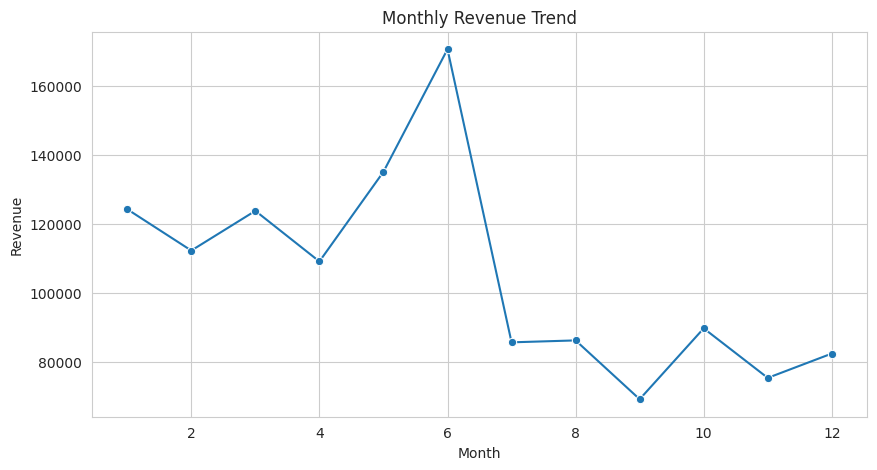

In [15]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()


# Business Insights

1. Certain products generate significantly higher revenue than others.

2. Revenue varies across payment methods, suggesting customer payment preferences.

3. Referral channels contribute differently to sales performance.

4. Monthly revenue trends reveal seasonal fluctuations in customer purchasing behavior.

5. Order status analysis identifies potential operational issues such as cancellations and returns.
